# Autonomous Rescue Drone - Dynamic Programming Solution
## Complete Implementation with Group ID Parameterization


## 0) Setup and Imports

In [3]:
import numpy as np
import random
from copy import deepcopy
from datetime import datetime
import platform
from itertools import product
import time
import matplotlib.pyplot as plt

print("Execution Timestamp:", datetime.now())
print("Machine ID         :", platform.node())
print("Operating System   :", platform.system())
print("\n✅ All imports successful")

Execution Timestamp: 2026-06-07 19:21:05.898997
Machine ID         : 2025aa05528
Operating System   : Linux

✅ All imports successful


## 1) Custom Drone Rescue Environment with Group ID Parameterization

In [5]:
class DroneRescue:
    """
    Custom Drone Rescue Environment parameterized by Group ID.
    """

    def __init__(self, group_id):
        """
        Initialize environment based on group_id.
        """
        self.group_id = group_id
        self.last_digit = group_id % 10

        # GRID CONFIGURATION (Based on Group ID)
        if self.last_digit in [0, 1, 2, 3, 4]:
            self.rows = 5
            self.cols = 5
            self.max_steps = 50
            self.wind_prob = 0.20
            self.num_rescue_targets = 2
            self.num_charging_stations = 1
            self.num_danger_zones = 3
            self.num_blocked_cells = 2
        else:  # last_digit in [5, 6, 7, 8, 9]
            self.rows = 6
            self.cols = 6
            self.max_steps = 75
            self.wind_prob = 0.30
            self.num_rescue_targets = 3
            self.num_charging_stations = 2
            self.num_danger_zones = 4
            self.num_blocked_cells = 3

        # BATTERY CONFIGURATION (Based on Group ID)
        if self.last_digit % 2 == 0:  # Even digit
            self.max_battery = 10
        else:  # Odd digit
            self.max_battery = 15

        # ACTION SPACE
        self.actions = {
            0: "UP",
            1: "DOWN",
            2: "LEFT",
            3: "RIGHT",
            4: "HOVER"
        }

        # FIXED STARTING POSITION (Top-left corner)
        self.start_pos = (0, 0)

        # SEED FOR REPRODUCIBILITY
        np.random.seed(group_id)
        random.seed(group_id)

        # PLACEMENT LOGIC (Deterministic based on group_id)
        self._place_entities()

        # REWARD STRUCTURE
        self.reward_mapping = {
            "rescue": 20,
            "danger": -10,
            "battery_exhausted": -20,
            "charging_station": 5,
            "regular_move": -1
        }

        self.reset()

    def _place_entities(self):
        """Place entities deterministically based on group_id."""
        valid_positions = []
        for r in range(self.rows):
            for c in range(self.cols):
                if (r, c) != self.start_pos:
                    valid_positions.append((r, c))

        random.shuffle(valid_positions)

        idx = 0
        self.rescue_targets = valid_positions[idx:idx+self.num_rescue_targets]
        idx += self.num_rescue_targets

        self.charging_stations = valid_positions[idx:idx+self.num_charging_stations]
        idx += self.num_charging_stations

        self.danger_zones = valid_positions[idx:idx+self.num_danger_zones]
        idx += self.num_danger_zones

        self.blocked_cells = valid_positions[idx:idx+self.num_blocked_cells]
        idx += self.num_blocked_cells

        available = [p for p in valid_positions
                    if p not in self.rescue_targets
                    and p not in self.charging_stations
                    and p not in self.danger_zones
                    and p not in self.blocked_cells]
        num_wind = min(2, len(available))
        self.wind_cells = available[:num_wind]

    def reset(self):
        """Reset environment to initial state."""
        self.position = self.start_pos
        self.battery = self.max_battery
        self.rescued = {target: False for target in self.rescue_targets}
        self.steps = 0
        return self.get_state()

    def get_state(self):
        """Return current state representation."""
        rescue_status = tuple(int(self.rescued[t]) for t in self.rescue_targets)
        return (self.position[0], self.position[1], self.battery, rescue_status)

    def valid_actions(self):
        """Return list of valid action indices."""
        return list(self.actions.keys())

    def is_terminal(self):
        """Check if episode has terminated."""
        all_rescued = all(self.rescued.values())
        if self.battery <= 0:
            return True
        if all_rescued:
            return True
        if self.steps >= self.max_steps:
            return True
        return False

    def move(self, action):
        """Calculate new position based on action."""
        r, c = self.position

        if action == 0:  # UP
            nr, nc = r - 1, c
        elif action == 1:  # DOWN
            nr, nc = r + 1, c
        elif action == 2:  # LEFT
            nr, nc = r, c - 1
        elif action == 3:  # RIGHT
            nr, nc = r, c + 1
        elif action == 4:  # HOVER
            nr, nc = r, c
        else:
            nr, nc = r, c

        if nr < 0 or nr >= self.rows or nc < 0 or nc >= self.cols:
            return self.position
        if (nr, nc) in self.blocked_cells:
            return self.position
        return (nr, nc)

    def apply_wind(self, intended_action):
        """Apply stochastic wind disturbance."""
        if self.position not in self.wind_cells:
            return intended_action
        if intended_action == 4:  # HOVER not affected
            return intended_action
        if random.random() < self.wind_prob:
            return random.choice([0, 1, 2, 3])
        return intended_action

    def step(self, action):
        """Execute one step in environment."""
        reward = self.reward_mapping["regular_move"]  # -1
        self.steps += 1

        # HOVER LOGIC
        if action == 4:
            if self.position in self.charging_stations:
                self.battery = min(self.max_battery, self.battery + 2)
            else:
                self.battery -= 1
        else:
            self.battery -= 1
            actual_action = self.apply_wind(action)
            self.position = self.move(actual_action)

        # CHECK CHARGING STATION
        if self.position in self.charging_stations:
            reward += self.reward_mapping["charging_station"]  # +5
            self.battery = self.max_battery

        # CHECK RESCUE TARGET
        if self.position in self.rescue_targets:
            if not self.rescued[self.position]:
                self.rescued[self.position] = True
                reward += self.reward_mapping["rescue"]  # +20

        # CHECK DANGER ZONE
        if self.position in self.danger_zones:
            reward += self.reward_mapping["danger"]  # -10

        done = self.is_terminal()

        if self.battery <= 0:
            reward += self.reward_mapping["battery_exhausted"]  # -20

        next_state = self.get_state()
        return next_state, reward, done

    def render(self):
        """Render environment grid."""
        grid = [["F" for _ in range(self.cols)] for _ in range(self.rows)]

        sr, sc = self.start_pos
        grid[sr][sc] = "S"

        for r, c in self.danger_zones:
            grid[r][c] = "D"
        for r, c in self.charging_stations:
            grid[r][c] = "C"
        for r, c in self.wind_cells:
            grid[r][c] = "W"
        for r, c in self.blocked_cells:
            grid[r][c] = "X"
        for r, c in self.rescue_targets:
            if not self.rescued[(r, c)]:
                grid[r][c] = "R"

        dr, dc = self.position
        grid[dr][dc] = "A"

        print("\n" + "="*50)
        print(f"Grid Layout ({self.rows}×{self.cols})")
        print("="*50)
        for row in grid:
            print(" ".join(row))

        print(f"\nBattery    : {self.battery}/{self.max_battery}")
        print(f"Steps      : {self.steps}/{self.max_steps}")
        rescued_count = sum(self.rescued.values())
        print(f"Rescued    : {rescued_count}/{len(self.rescue_targets)}")
        print(f"Wind Prob  : {self.wind_prob*100:.0f}%")
        print("="*50)

print("✅ DroneRescue class defined")

✅ DroneRescue class defined


## 2) Dynamic Programming Solution (Value Iteration)

In [7]:
class ValueIteration:
    """Solves the MDP using Value Iteration."""

    def __init__(self, env, gamma=0.95, theta=1e-3):
        self.env = env
        self.gamma = gamma
        self.theta = theta
        self.V = {}
        self.policy = {}
        self.states = []

    def enumerate_states(self):
        """Enumerate all reachable states in the MDP."""
        states = []

        valid_positions = []
        for r in range(self.env.rows):
            for c in range(self.env.cols):
                if (r, c) not in self.env.blocked_cells:
                    valid_positions.append((r, c))

        rescue_combinations = list(
            product([0, 1], repeat=len(self.env.rescue_targets))
        )

        for pos in valid_positions:
            for battery in range(1, self.env.max_battery + 1):
                for rescue_status in rescue_combinations:
                    state = (pos[0], pos[1], battery, rescue_status)
                    states.append(state)

        self.states = states
        return states

    def load_state(self, state):
        """Set environment to a specific state."""
        row, col, battery, rescue_status = state
        self.env.position = (row, col)
        self.env.battery = battery
        for i, target in enumerate(self.env.rescue_targets):
            self.env.rescued[target] = bool(rescue_status[i])

    def simulate_action(self, state, action):
        """Simulate an action from a state."""
        self.load_state(state)
        next_state, reward, _ = self.env.step(action)
        return next_state, reward

    def value_iteration(self):
        """Run Value Iteration algorithm."""
        print("\n" + "="*60)
        print("RUNNING VALUE ITERATION")
        print("="*60)

        self.enumerate_states()
        for state in self.states:
            self.V[state] = 0.0

        iterations = 0
        start_time = time.time()

        while True:
            delta = 0

            for state in self.states:
                self.load_state(state)

                if self.env.is_terminal():
                    continue

                old_value = self.V[state]
                action_values = []

                for action in self.env.valid_actions():
                    next_state, reward = self.simulate_action(state, action)
                    value = reward + self.gamma * self.V.get(next_state, 0)
                    action_values.append(value)

                best_value = max(action_values)
                self.V[state] = best_value
                delta = max(delta, abs(old_value - best_value))

            iterations += 1

            if delta < self.theta:
                break

        runtime = time.time() - start_time

        print(f"Total States    : {len(self.states)}")
        print(f"Iterations      : {iterations}")
        print(f"Runtime         : {runtime:.4f} seconds")
        print(f"Final Delta     : {delta:.10f}")
        print(f"Theta (threshold): {self.theta}")
        print("="*60)

        return iterations, runtime, delta

    def extract_policy(self):
        """Extract optimal policy from value function."""
        action_names = {0: "↑", 1: "↓", 2: "←", 3: "→", 4: "H"}

        for state in self.states:
            self.load_state(state)

            if self.env.is_terminal():
                self.policy[state] = "T"
                continue

            best_action = None
            best_value = float("-inf")

            for action in self.env.valid_actions():
                next_state, reward = self.simulate_action(state, action)
                value = reward + self.gamma * self.V.get(next_state, 0)

                if value > best_value:
                    best_value = value
                    best_action = action

            self.policy[state] = action_names[best_action]

        return self.policy

print("✅ ValueIteration class defined")

✅ ValueIteration class defined


## TASK 1: Environment Configuration with Group ID

In [9]:
print("\n" + "="*70)
print("TASK 1: ENVIRONMENT CONFIGURATION WITH GROUP ID PARAMETERIZATION")
print("="*70)

# CHANGE THIS FOR DIFFERENT GROUP ID
group_id = 164  # Example: Group ID 5 (last digit 5 → 6×6 grid, 15 battery, 30% wind)

print(f"\nGroup ID: {group_id}")
print(f"Last Digit: {group_id % 10}")

env = DroneRescue(group_id)

print(f"\nGrid Configuration:")
print(f"  Grid Size: {env.rows}×{env.cols}")
print(f"  Max Battery: {env.max_battery}")
print(f"  Wind Probability: {env.wind_prob*100:.0f}%")
print(f"  Max Steps: {env.max_steps}")

print(f"\nEntity Placement:")
print(f"  Rescue Targets: {env.num_rescue_targets} at {env.rescue_targets}")
print(f"  Charging Stations: {env.num_charging_stations} at {env.charging_stations}")
print(f"  Danger Zones: {env.num_danger_zones} at {env.danger_zones}")
print(f"  Blocked Cells: {env.num_blocked_cells} at {env.blocked_cells}")
print(f"  Wind Zones: {len(env.wind_cells)} at {env.wind_cells}")

print(f"\nInitial State:")
state = env.reset()
print(f"  Position: {env.position}")
print(f"  Battery: {env.battery}")
print(f"  Rescued: {list(env.rescued.values())}")

env.render()


TASK 1: ENVIRONMENT CONFIGURATION WITH GROUP ID PARAMETERIZATION

Group ID: 164
Last Digit: 4

Grid Configuration:
  Grid Size: 5×5
  Max Battery: 10
  Wind Probability: 20%
  Max Steps: 50

Entity Placement:
  Rescue Targets: 2 at [(1, 3), (4, 2)]
  Charging Stations: 1 at [(2, 1)]
  Danger Zones: 3 at [(4, 0), (3, 4), (2, 2)]
  Blocked Cells: 2 at [(4, 1), (0, 2)]
  Wind Zones: 2 at [(1, 1), (1, 0)]

Initial State:
  Position: (0, 0)
  Battery: 10
  Rescued: [False, False]

Grid Layout (5×5)
A F X F F
W W F R F
F C D F F
F F F F D
D X R F F

Battery    : 10/10
Steps      : 0/50
Rescued    : 0/2
Wind Prob  : 20%


## TASK 2: Dynamic Programming Solution

In [11]:
print("\n" + "="*70)
print("TASK 2: DYNAMIC PROGRAMMING SOLUTION")
print("="*70)

agent = ValueIteration(env, gamma=0.95, theta=1e-3)
iterations, runtime, delta = agent.value_iteration()

policy = agent.extract_policy()

print(f"\nPolicy Extracted: {len(policy)} states mapped to actions")

print(f"\nSample State Values (first 15 states with non-zero value):")
count = 0
for state, value in agent.V.items():
    if count >= 15:
        break
    if value != 0:
        print(f"  {state} → V = {value:.2f}")
        count += 1


TASK 2: DYNAMIC PROGRAMMING SOLUTION

RUNNING VALUE ITERATION
Total States    : 920
Iterations      : 2
Runtime         : 0.0040 seconds
Final Delta     : 0.0000000000
Theta (threshold): 0.001

Policy Extracted: 920 states mapped to actions

Sample State Values (first 15 states with non-zero value):
  (0, 0, 1, (0, 0)) → V = -21.00
  (0, 0, 1, (0, 1)) → V = -21.00
  (0, 0, 1, (1, 0)) → V = -21.00
  (0, 0, 2, (0, 0)) → V = -1.00
  (0, 0, 2, (0, 1)) → V = -1.00
  (0, 0, 2, (1, 0)) → V = -1.00
  (0, 0, 3, (0, 0)) → V = -1.00
  (0, 0, 3, (0, 1)) → V = -1.00
  (0, 0, 3, (1, 0)) → V = -1.00
  (0, 0, 4, (0, 0)) → V = -1.00


## TASK 3: Policy Visualization

In [13]:
print("\n" + "="*70)
print("TASK 3: POLICY VISUALIZATION")
print("="*70)

battery_level = env.max_battery
rescue_status = tuple([0] * len(env.rescue_targets))

print(f"\nOptimal Policy Grid (Battery={battery_level}, No Rescues)")
print("(Arrows show optimal movement direction)\n")

policy_grid = [["" for _ in range(env.cols)] for _ in range(env.rows)]

for r in range(env.rows):
    for c in range(env.cols):
        if (r, c) in env.blocked_cells:
            policy_grid[r][c] = "X"
        elif (r, c) in env.danger_zones:
            policy_grid[r][c] = "D"
        elif (r, c) in env.charging_stations:
            policy_grid[r][c] = "C"
        elif (r, c) in env.rescue_targets:
            policy_grid[r][c] = "R"
        else:
            state = (r, c, battery_level, rescue_status)
            action = agent.policy.get(state, "?")
            policy_grid[r][c] = action

for row in policy_grid:
    print(" ".join(row))

print("\nLegend: ↑↓←→ = Direction, H = Hover, C = Charging, R = Rescue, D = Danger, X = Blocked, T = Terminal")


TASK 3: POLICY VISUALIZATION

Optimal Policy Grid (Battery=10, No Rescues)
(Arrows show optimal movement direction)

T T X T T
T T T R T
T C D T T
T T T T D
D X R T T

Legend: ↑↓←→ = Direction, H = Hover, C = Charging, R = Rescue, D = Danger, X = Blocked, T = Terminal


## TASK 4: State-Value Analysis


TASK 4: STATE-VALUE ANALYSIS

State-Value Heatmap Analysis:
  Battery Level: 10
  Rescue Status: All targets not yet rescued
  Min Value: 0.00
  Max Value: 0.00
  Mean Value: 0.00


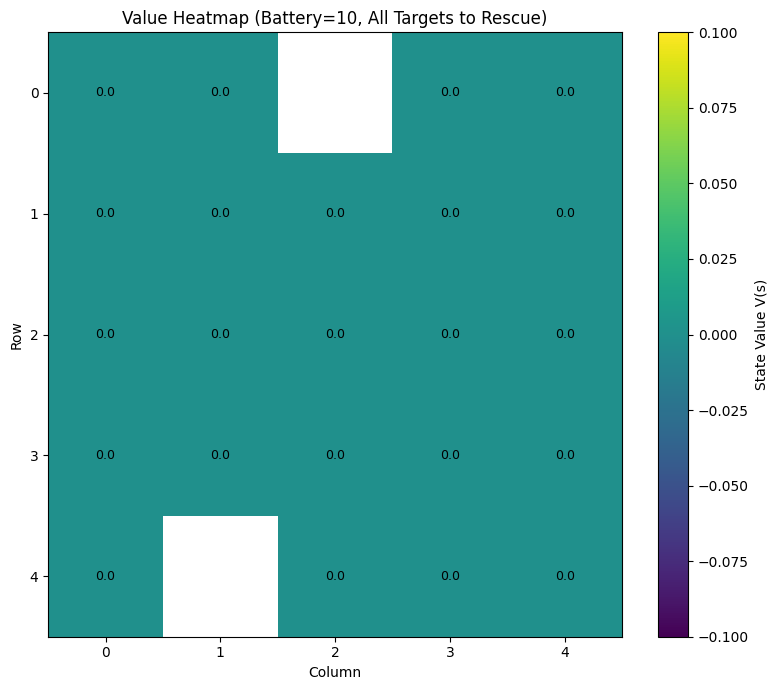

In [15]:
print("\n" + "="*70)
print("TASK 4: STATE-VALUE ANALYSIS")
print("="*70)

heatmap = np.zeros((env.rows, env.cols))

for r in range(env.rows):
    for c in range(env.cols):
        if (r, c) in env.blocked_cells:
            heatmap[r, c] = np.nan
        else:
            state = (r, c, battery_level, rescue_status)
            heatmap[r, c] = agent.V.get(state, 0.0)

print(f"\nState-Value Heatmap Analysis:")
print(f"  Battery Level: {battery_level}")
print(f"  Rescue Status: All targets not yet rescued")
print(f"  Min Value: {np.nanmin(heatmap):.2f}")
print(f"  Max Value: {np.nanmax(heatmap):.2f}")
print(f"  Mean Value: {np.nanmean(heatmap):.2f}")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(heatmap, cmap='viridis', aspect='auto')
plt.colorbar(im, label="State Value V(s)")
ax.set_title(f"Value Heatmap (Battery={battery_level}, All Targets to Rescue)")
ax.set_xlabel("Column")
ax.set_ylabel("Row")

for r in range(env.rows):
    for c in range(env.cols):
        if not np.isnan(heatmap[r, c]):
            text_color = 'white' if heatmap[r, c] < 0 else 'black'
            ax.text(c, r, f"{heatmap[r, c]:.1f}",
                   ha='center', va='center', color=text_color, fontsize=9)

plt.tight_layout()
plt.show()

## TASK 5: DP Scalability & Curse of Dimensionality Discussion

In [17]:
print("\n" + "="*70)
print("TASK 5: DP SCALABILITY & CURSE OF DIMENSIONALITY")
print("="*70)

current_state_count = len(agent.states)

print(f"\nCurrent Configuration:")
print(f"  Grid: {env.rows}×{env.cols}")
print(f"  Rescue Targets: {len(env.rescue_targets)}")
print(f"  Valid Positions: {env.rows * env.cols - len(env.blocked_cells)}")
print(f"  Total States: {current_state_count:,}")

print(f"\nScalability Analysis:")

# 10x10 grid projection
grid_10x10_positions = (10 * 10) - 3
rescue_combos_2 = 2 ** 2
battery_options_10 = 10
states_10x10 = grid_10x10_positions * battery_options_10 * rescue_combos_2

print(f"  10×10 Grid with 2 rescue targets:")
print(f"    Estimated states: {states_10x10:,}")
print(f"    Growth factor: {states_10x10 / current_state_count:.1f}×")

# Add more rescue targets
rescue_combos_5 = 2 ** 5
states_10x10_5targets = grid_10x10_positions * battery_options_10 * rescue_combos_5

print(f"  10×10 Grid with 5 rescue targets:")
print(f"    Estimated states: {states_10x10_5targets:,}")
print(f"    Growth factor: {states_10x10_5targets / current_state_count:.1f}×")

print(f"\n" + "="*70)
print("CURSE OF DIMENSIONALITY DISCUSSION")
print("="*70)

discussion = f"""
1. STATE SPACE EXPLOSION:
   - Grid expansion: O(n²) growth in positions
   - Rescue targets: O(2^K) exponential in target count
   - Battery: O(b) linear growth
   - Combined: EXPONENTIAL growth

2. COMPUTATIONAL IMPLICATIONS:
   - Current: {current_state_count:,} states, {iterations} iterations, {runtime:.4f}s
   - 10×10 + 5 targets: ~{states_10x10_5targets:,} states
   - Estimated time: {runtime * (states_10x10_5targets / current_state_count):.2f}s
   - Memory: Scales linearly with state space

3. WHY DP BECOMES INFEASIBLE:
   - Must visit ALL states in each iteration
   - Each state requires action evaluation (5 actions)
   - Convergence depends on state space size
   - For 50×50+ grids: NOT PRACTICAL

4. DEEP REINFORCEMENT LEARNING ADVANTAGE:
   - Function approximation (Neural Networks) avoid enumeration
   - Learn generalizable representations
   - Scale to continuous/large spaces
   - Methods: DQN, PPO, Actor-Critic

5. REAL-WORLD AUTONOMOUS DRONE SYSTEMS:
   - Real grids: 1000×1000+ cells
   - Dynamic obstacles and weather
   - Continuous state spaces
   - Multiple objectives
   - Conclusion: Deep RL is ESSENTIAL
"""

print(discussion)
print("="*70)


TASK 5: DP SCALABILITY & CURSE OF DIMENSIONALITY

Current Configuration:
  Grid: 5×5
  Rescue Targets: 2
  Valid Positions: 23
  Total States: 920

Scalability Analysis:
  10×10 Grid with 2 rescue targets:
    Estimated states: 3,880
    Growth factor: 4.2×
  10×10 Grid with 5 rescue targets:
    Estimated states: 31,040
    Growth factor: 33.7×

CURSE OF DIMENSIONALITY DISCUSSION

1. STATE SPACE EXPLOSION:
   - Grid expansion: O(n²) growth in positions
   - Rescue targets: O(2^K) exponential in target count
   - Battery: O(b) linear growth
   - Combined: EXPONENTIAL growth

2. COMPUTATIONAL IMPLICATIONS:
   - Current: 920 states, 2 iterations, 0.0040s
   - 10×10 + 5 targets: ~31,040 states
   - Estimated time: 0.14s
   - Memory: Scales linearly with state space

3. WHY DP BECOMES INFEASIBLE:
   - Must visit ALL states in each iteration
   - Each state requires action evaluation (5 actions)
   - Convergence depends on state space size
   - For 50×50+ grids: NOT PRACTICAL

4. DEEP REIN

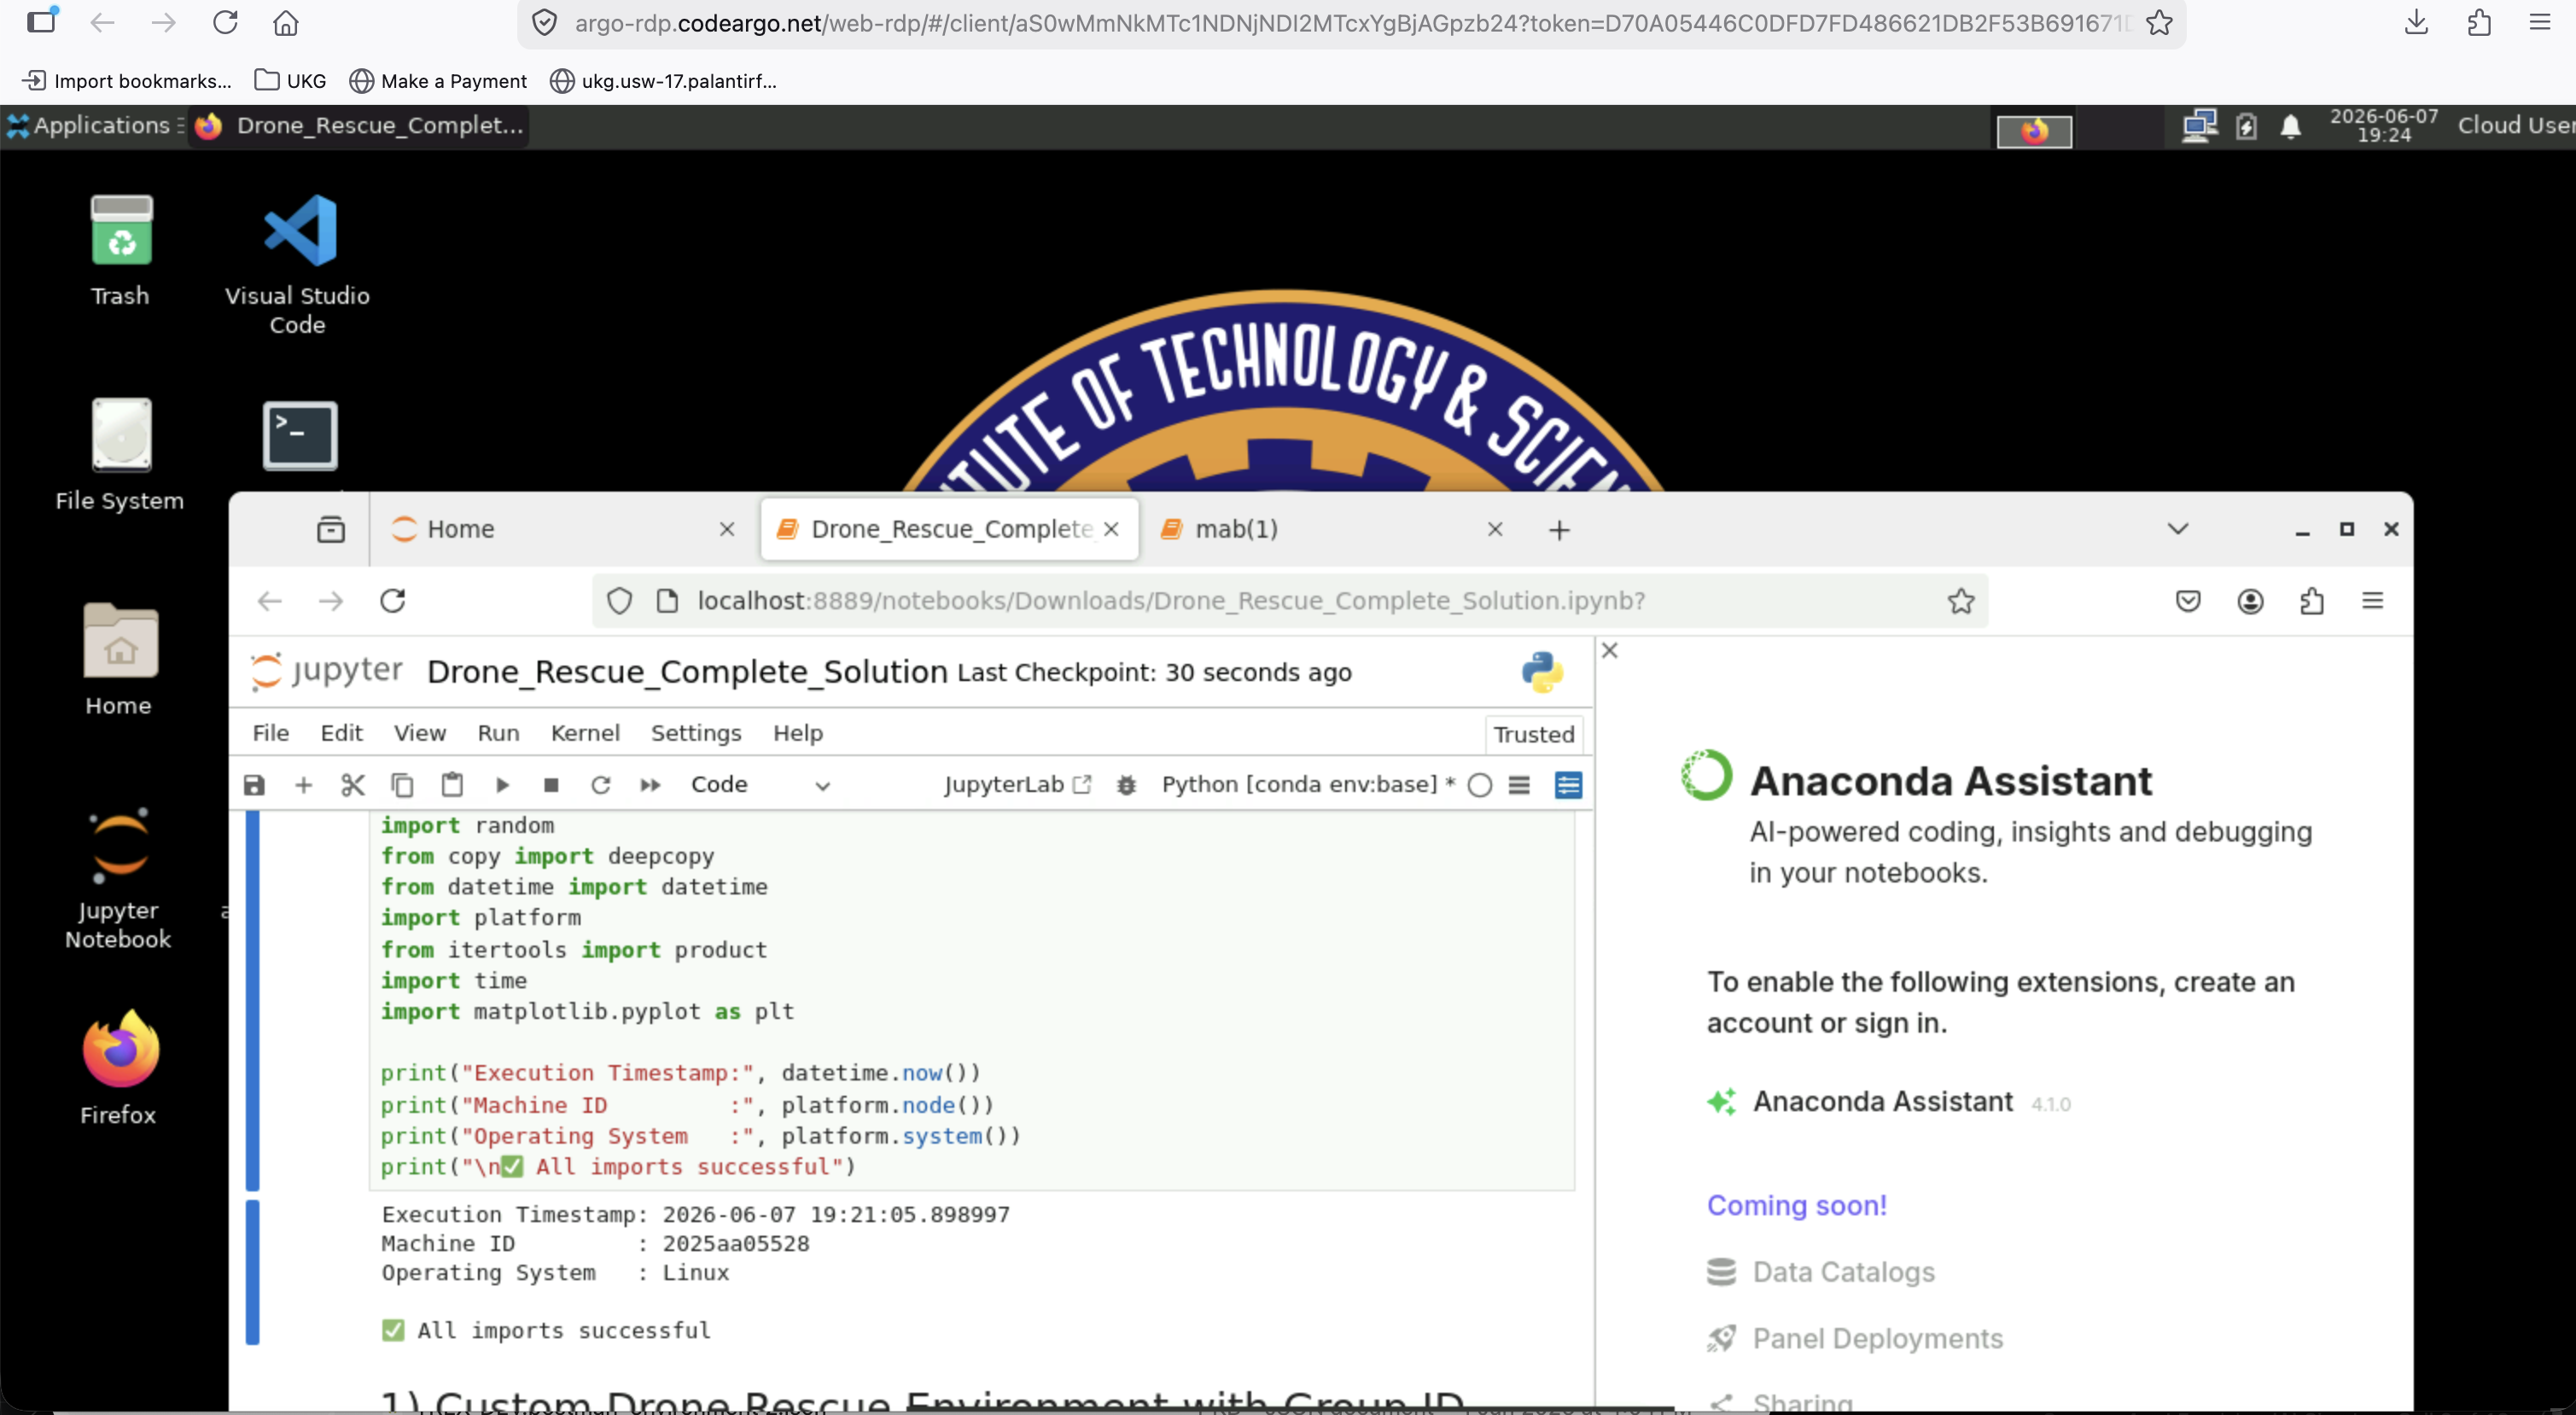